# SETTINGS

In [1]:
SITE = 'ch-tan'
SITE_LAT = 47.480611  # CH-TAN
SITE_LON = 8.911861  # CH-TAN

In [2]:
FIELDS = ['WD_ATM41_M1_2_1']
MEASUREMENT = 'WIND'

In [3]:
START = '2023-11-01 00:00:00'
STOP = '2025-06-05 00:00:00'

In [4]:
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Location of configuration files, needed e.g. for connection to database

# Imports

In [5]:
import importlib.metadata
import warnings
from datetime import datetime

# %matplotlib inline
import pandas as pd
# from bokeh.plotting import output_notebook, show
# output_notebook()
from dbc_influxdb import dbcInflux  # Needed for communicating with the database

from diive.core.plotting.timeseries import TimeSeries
from diive.core.times.times import DetectFrequency
from diive.pkgs.qaqc.meteoscreening import StepwiseMeteoScreeningDb

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"This page was last modified on: {dt_string}")
version_dbc = importlib.metadata.version("dbc_influxdb")
print(f"dbc-influxdb version: v{version_dbc}")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

This page was last modified on: 2025-08-29 16:00:54
dbc-influxdb version: v0.13.1
diive version: v0.89.0


In [6]:
BUCKET_RAW = f'{SITE}_raw'  # The 'bucket' where data are stored in the database, e.g., 'ch-lae_raw' contains all raw data for CH-LAE
print(f"Bucket containing raw data (source bucket): {BUCKET_RAW}")

Bucket containing raw data (source bucket): ch-tan_raw


## Connect to database

In [7]:
dbc = dbcInflux(dirconf=DIRCONF)

Reading configuration files was successful.
Connection to database works.


In [8]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

Fields in measurement WIND of bucket ch-tan_raw:
#1  ch-tan_raw  WIND  WD_ATM41_M1_2_1
#2  ch-tan_raw  WIND  WSG_ATM41_M1_2_1
#3  ch-tan_raw  WIND  WS_ATM41_M1_2_1
Found 3 fields in measurement WIND of bucket ch-tan_raw.


['WD_ATM41_M1_2_1', 'WSG_ATM41_M1_2_1', 'WS_ATM41_M1_2_1']

</br>

</br>

# **DOWNLOAD DATA FROM DATABASE WITH `dbc-influxdb`**
- Here the Python library `dbc-influxdb` is used to download data from the database.
- The name of the library means **d**ata**b**ase **c**ommunication using **influxdb**.
- You can find the source code of `dbc-influxdb` [here](https://gitlab.ethz.ch/poet/dbc-influxdb).
- There is no need to adjust the settings here, the variables given earlier (above) are directly used.
- At this point we have already established the connection to the database and stored the connection details in the variable `dbc`.
- Now we can use the method `dbc.download()` to start the data download.

## Download data

In [9]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)


DOWNLOADING
    from bucket ch-tan_raw
    variables ['WD_ATM41_M1_2_1']
    from measurements ['WIND']
    from data version ['raw']
    between 2023-11-01 00:00:00 and 2025-06-05 00:00:00
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-tan_raw") |> range(start: 2023-11-01T00:00:00+01:00, stop: 2025-06-05T00:00:00+01:00) |> filter(fn: (r) => r["_measurement"] == "WIND") |> filter(fn: (r) => r["data_version"] == "raw") |> filter(fn: (r) => r["_field"] == "WD_ATM41_M1_2_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-tan_raw") |> range(start: 2023-11-01T00:00:00+01:00, stop: 2025-06-05T00:00:00+01:00) |> filter(fn: (r) => r["_measurement"] == "WIND") |> filter(fn: (r) => r["data_version"] == "raw") |> filter(fn: (r) => r["_field"] == "WD_ATM41_M1_2_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
querystring was constructed from:
    bucketstring: from(bucket: "ch-tan_ra

## Check downloaded data
### `dbc` downloads three variables:
- `data_simple`: This is the simplest data download. It contains only the high-resolution variable(s) from the specified measurement. Each variable is in a separate column. Since different variables, can have different time resolutions, the highest time resolution across the variables is used as the index. This means that lower resolution variables will show gaps in the higher resolution timestamp.
- `data_detailed`: This is the most important variable for the MeteoScreening from the database, because it contains not only the high-resolution time series of the variable(s), but also their tags. The tags are important when uploading data to the database. This is a very special format, because data for each variable are stored in a dictionary. A dictionary is a data structure that stores key-value pairs. The key is the variable name (e.g., `TA_NABEL_T1_35_1`) and the value is a complete dataframe that contains the time series of the respective variable and all tags.
- `assigned_measurements`: An auxiliary variable that is useful to check whether the measurement of the variable(s) is correct. In case we are screening air temperatures, the measurement must be `TA`.

#### `data_simple`
- Simply contains the time series of the measured variable(s) in a nice-to-look-at dataframe.

In [10]:
data_simple

,WD_ATM41_M1_2_1
TIMESTAMP_END,
2023-11-18 23:04:00,243.8
2023-11-18 23:05:00,226.1
2023-11-18 23:06:00,221.6
2023-11-18 23:07:00,253.0
2023-11-18 23:08:00,215.7
...,...
2025-06-04 23:55:00,203.5
2025-06-04 23:56:00,215.8
2025-06-04 23:57:00,206.2


#### `data_detailed`
- Dictionary of key-value pairs: the variable name is the key, the respective data (measured time series and tags) are the values

In [11]:
data_detailed

{'WD_ATM41_M1_2_1':                                                config_filetype data_raw_freq data_version filegroup freq gain hpos offset raw_units      raw_varname repl    site units          varname vpos  WD_ATM41_M1_2_1
 TIMESTAMP_END                                                                                                                                                                                                 
 2023-11-18 23:04:00  TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN           min          raw  10_meteo  min  1.0   M1    0.0       deg  WD_ATM41_M1_2_1    1  CH-TAN   deg  WD_ATM41_M1_2_1    2            243.8
 2023-11-18 23:05:00  TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN           min          raw  10_meteo  min  1.0   M1    0.0       deg  WD_ATM41_M1_2_1    1  CH-TAN   deg  WD_ATM41_M1_2_1    2            226.1
 2023-11-18 23:06:00  TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN           min          raw  10_meteo  min  1.0   M1    0.0       deg  WD_ATM41_M1_2_1

<br>
Since the output above is not so nice to look at, we loop through the dictionary and display the first and last records for each variable:

In [12]:
for varname, frame in data_detailed.items():
    print(f"{'-' * 40}\nData for {varname}:")
    display(frame)

----------------------------------------
Data for WD_ATM41_M1_2_1:


,config_filetype,data_raw_freq,data_version,filegroup,freq,gain,hpos,offset,raw_units,raw_varname,repl,site,units,varname,vpos,WD_ATM41_M1_2_1
TIMESTAMP_END,,,,,,,,,,,,,,,,
2023-11-18 23:04:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,243.8
2023-11-18 23:05:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,226.1
2023-11-18 23:06:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,221.6
2023-11-18 23:07:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,253.0
2023-11-18 23:08:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,215.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 23:55:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,203.5
2025-06-04 23:56:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,215.8
2025-06-04 23:57:00,TAN10-RAW-BOX1-202311182304-TOA5-DAT-1MIN,min,raw,10_meteo,min,1.0,M1,0.0,deg,WD_ATM41_M1_2_1,1,CH-TAN,deg,WD_ATM41_M1_2_1,2,206.2


#### `assigned_measurements`
- Contains the *automatically* detected measurement for the selected variables, useful as check to make sure the variable was properly identified.

In [13]:
assigned_measurements

{'WD_ATM41_M1_2_1': 'WIND'}

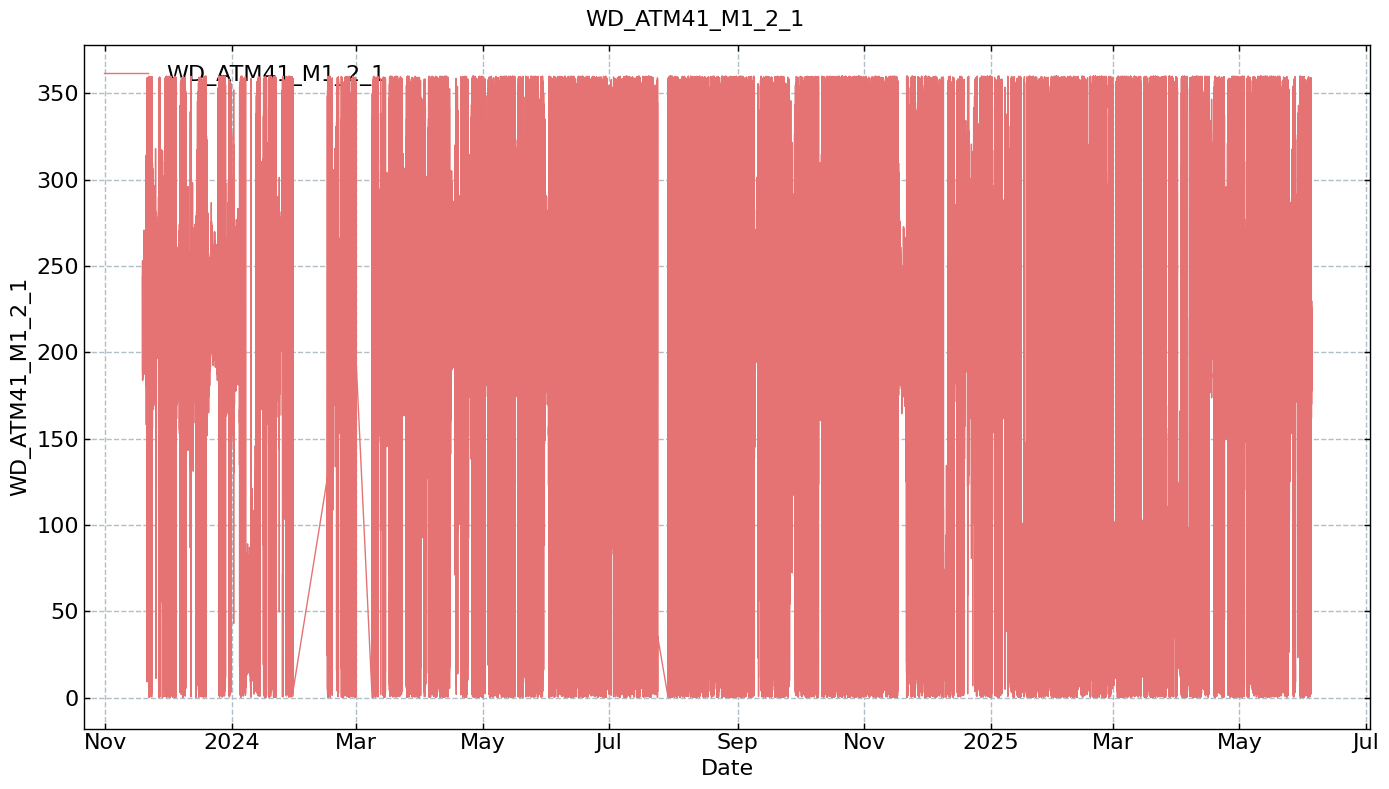

In [16]:
for varname, frame in data_detailed.items():
    # TimeSeries(series=frame[varname]).plot_interactive()
    TimeSeries(series=frame[varname]).plot()

# Export

In [18]:
data_detailed[FIELDS[0]].to_csv("14.1_wind_direction_highres.csv")

# End of notebook

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-08-29 16:09:19
